<h1 align=center> Facial Expression Recognition With Keras</h1>

<h2>Import Libraries</h2>

In [1]:
# Import các thư viện cần thiết cho deep learning và xử lý dữ liệu

# Numpy: Thư viện xử lý mảng và tính toán số học
import numpy as np

# Seaborn: Thư viện vẽ đồ thị thống kê đẹp mắt
import seaborn as sns

# Matplotlib: Thư viện vẽ đồ thị cơ bản
import matplotlib.pyplot as plt

# Utils: Module tự định nghĩa chứa các hàm tiện ích
import utils

# Os: Thao tác với file và folder
import os

# Magic command để hiển thị đồ thị trực tiếp trong notebook
%matplotlib inline

# ImageDataGenerator: Tạo batch dữ liệu ảnh từ folder, hỗ trợ data augmentation (tăng cường dữ liệu)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Các layer cần thiết để xây dựng CNN
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D

# Model và Sequential: API để xây dựng mạng neural network
from tensorflow.keras.models import Model, Sequential

# Adam: Thuật toán optimizer (tối ưu hóa) hiện đại, hiệu quả
from tensorflow.keras.optimizers import Adam

# ModelCheckpoint: Lưu model tốt nhất trong quá trình training
# ReduceLROnPlateau: Giảm learning rate khi model không cải thiện
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# plot_model: Vẽ kiến trúc model dưới dạng đồ thị
from tensorflow.keras.utils import plot_model

# SVG, Image: Hiển thị ảnh và đồ thị trong notebook
from IPython.display import SVG, Image

# PlotLossesKeras: Vẽ đồ thị loss và accuracy theo thời gian thực khi training
from livelossplot import PlotLossesKeras
from livelossplot.keras import PlotLossesCallback

# TensorFlow: Framework deep learning chính
import tensorflow as tf

# In phiên bản TensorFlow để kiểm tra
print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.8.0


import sys
print(sys.executable)

In [2]:
import sys
print(sys.executable)

c:\Users\trinh\Downloads\BTLXuLyAnh\XuLyAnh-main\.venv\Scripts\python.exe


In [3]:
import sys
print(sys.executable)

c:\Users\trinh\Downloads\BTLXuLyAnh\XuLyAnh-main\.venv\Scripts\python.exe


In [4]:
!pip install livelossplot

In [5]:
!pip install tensorflow

In [6]:
!pip install seaborn

In [7]:
!pip install seaborn

<h2>Plotting Sample Images</h2>

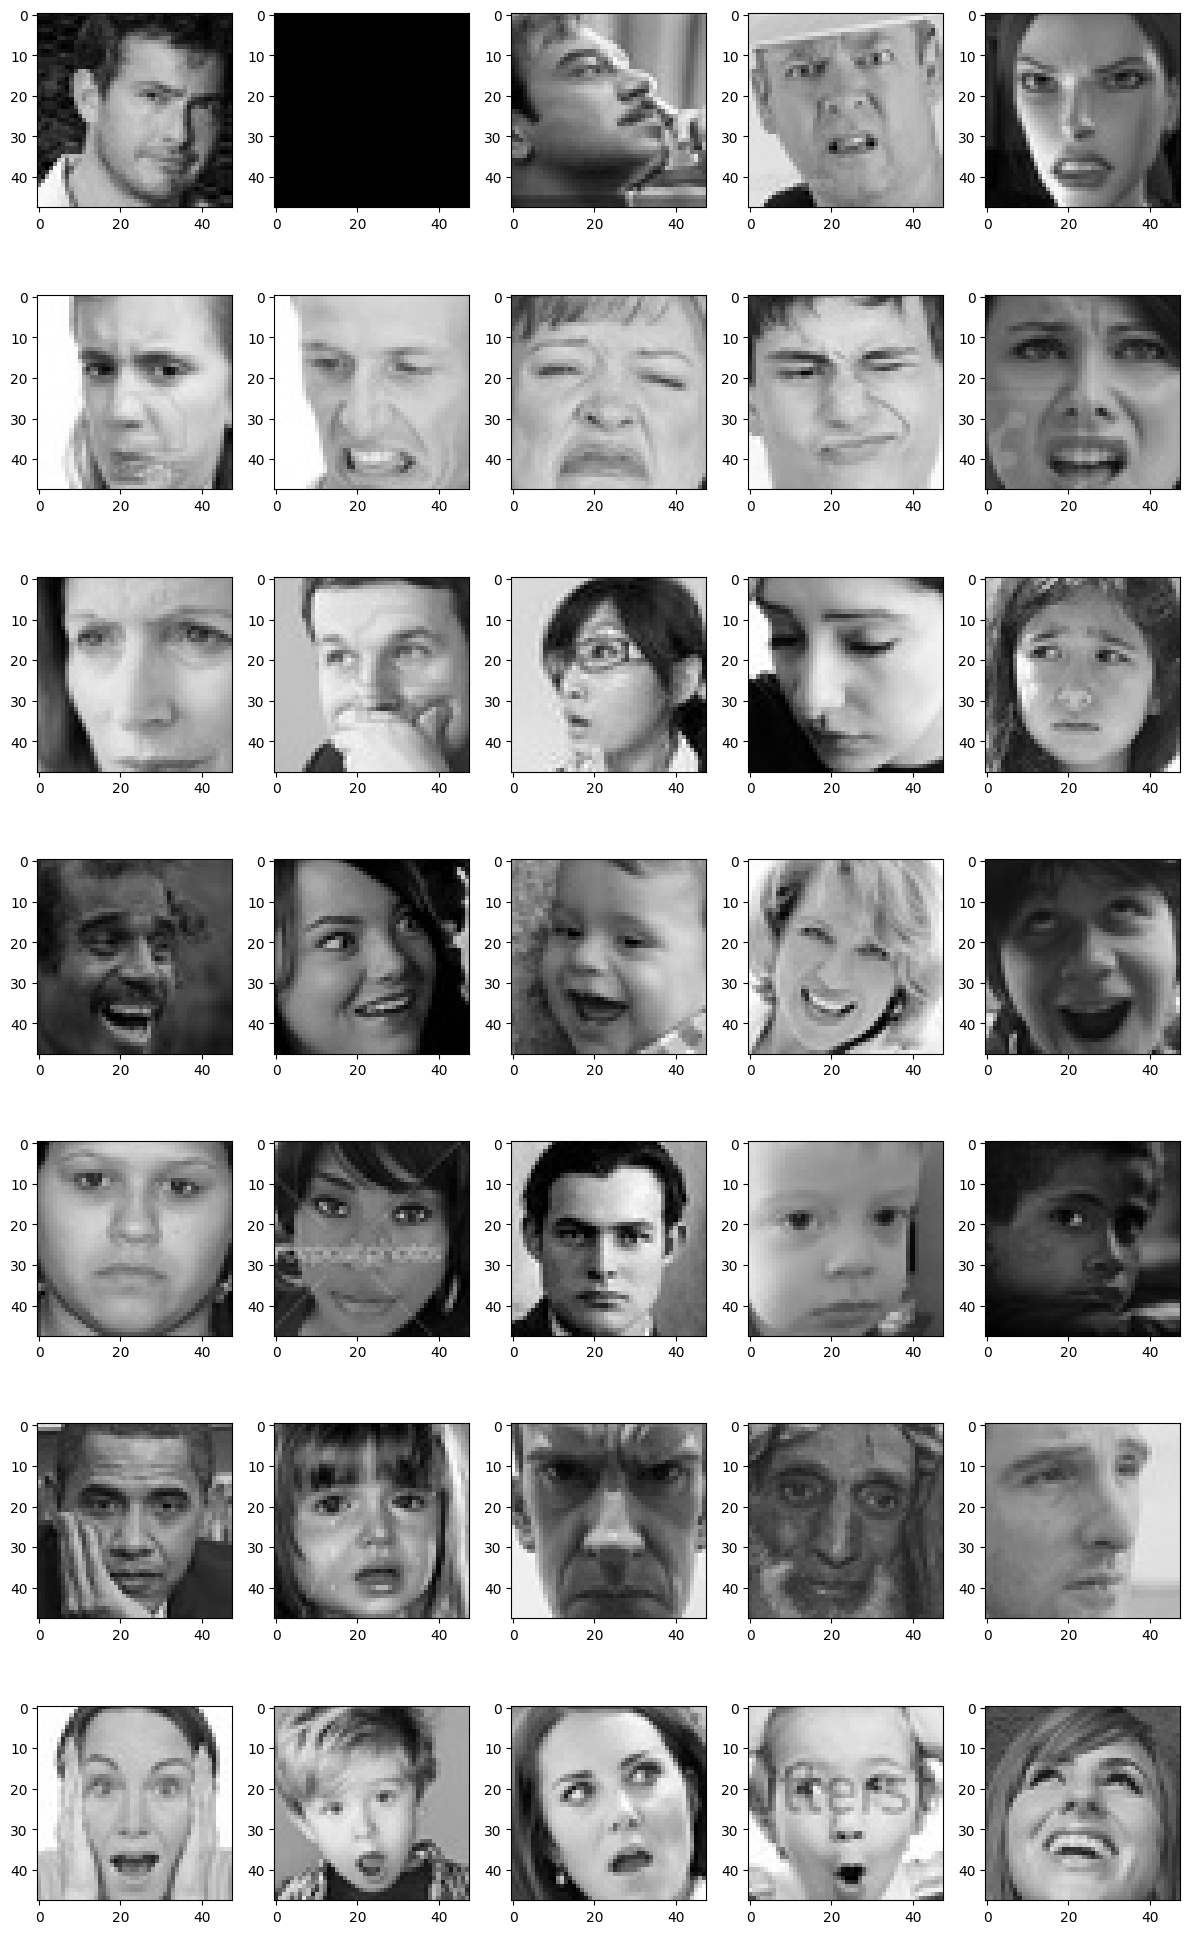

In [8]:
# Vẽ một số ảnh mẫu từ dataset FER (Facial Expression Recognition)
# Giúp hiểu rõ hơn về dữ liệu đầu vào: kích thước, chất lượng, các loại cảm xúc
utils.datasets.fer.plot_example_images(plt).show()

In [9]:
# Đếm số lượng ảnh trong mỗi folder cảm xúc trong tập train
# Giúp hiểu phân bố dữ liệu: liệu có cân bằng giữa các class không?
# os.listdir("train/") → Lấy danh sách các folder (angry, happy, sad,...)
for expression in os.listdir("train/"):
    # Đếm số file ảnh trong mỗi folder cảm xúc
    print(str(len(os.listdir("train/"+expression))) + " "+expression + " images")

3995 angry images
436 disgust images
4097 fear images
7215 happy images
4965 neutral images
4830 sad images
3171 surprise images


<h2>Generating Training And Validation Batches</h2>

In [10]:
# Thiết lập các tham số cho việc training

# Kích thước ảnh đầu vào cho model (48x48 pixels)
# Tất cả ảnh sẽ được resize về kích thước này
img_size = 48

# Batch size: Số lượng ảnh xử lý cùng lúc trong 1 iteration
# Batch size càng lớn → Training nhanh hơn nhưng tốn RAM nhiều hơn
batch_size = 64

# ============ TẠO DATA GENERATOR CHO TẬP TRAINING ============
# ImageDataGenerator: Công cụ tạo dữ liệu training với data augmentation
# horizontal_flip=True: Lật ngẫu nhiên ảnh theo chiều ngang
# → Tăng độ đa dạng dữ liệu, giúp model học tốt hơn, tránh overfitting
datagen_train = ImageDataGenerator(horizontal_flip=True)

# flow_from_directory: Đọc ảnh trực tiếp từ folder, tự động gán nhãn dựa trên tên folder
train_generator = datagen_train.flow_from_directory(
    "train/",                           # Đường dẫn đến folder chứa dữ liệu training
    target_size=(img_size, img_size),   # Resize tất cả ảnh về 48x48
    color_mode='grayscale',             # Chuyển ảnh sang grayscale (1 channel thay vì 3 RGB)
    batch_size=batch_size,              # Số ảnh trong mỗi batch
    class_mode='categorical',           # Dạng nhãn: categorical = one-hot encoding (vd: [0,1,0,0,0,0,0])
    shuffle=True                        # Xáo trộn dữ liệu mỗi epoch để tránh model học theo thứ tự
)

# ============ TẠO DATA GENERATOR CHO TẬP VALIDATION ============
# Tương tự như train nhưng dùng để đánh giá model trong quá trình training
datagen_validation = ImageDataGenerator(horizontal_flip=True)

validation_generator = datagen_validation.flow_from_directory(
    "test/",                            # Đường dẫn đến folder chứa dữ liệu validation/test
    target_size=(img_size, img_size),   # Resize về 48x48
    color_mode='grayscale',             # Grayscale
    batch_size=batch_size,              # Batch size
    class_mode='categorical',           # Categorical labels
    shuffle=False                       # KHÔNG xáo trộn để đánh giá nhất quán
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


<h2>Creating CNN Model</h2>

In [11]:
# ============ XÂY DỰNG KIẾN TRÚC CNN (Convolutional Neural Network) ============

# Sequential: Model tuần tự - các layer xếp chồng lên nhau theo thứ tự
model = Sequential()

# ============ BLOCK 1: CONVOLUTIONAL LAYER ============
# Conv2D: Layer tích chập 2D - trích xuất các đặc trưng (features) từ ảnh
# 64: Số filter (kernel) - mỗi filter học một đặc trưng khác nhau (cạnh, góc, texture...)
# (3,3): Kích thước filter 3x3 pixels
# padding='same': Giữ nguyên kích thước ảnh sau khi conv (thêm padding xung quanh)
# input_shape=(48,48,1): Kích thước ảnh đầu vào 48x48x1 (grayscale)
model.add(Conv2D(64, (3,3), padding='same', input_shape=(48,48,1)))

# BatchNormalization: Chuẩn hóa output của layer trước
# → Giúp training nhanh hơn, ổn định hơn, tránh overfitting
model.add(BatchNormalization())

# Activation('relu'): Hàm kích hoạt ReLU (Rectified Linear Unit)
# ReLU(x) = max(0, x) → Giữ giá trị dương, loại bỏ giá trị âm
# → Thêm tính phi tuyến, giúp model học các pattern phức tạp
model.add(Activation('relu'))

# MaxPooling2D: Giảm kích thước ảnh xuống 1/2 (pooling 2x2)
# → Giảm số lượng tham số, tăng tốc training, tránh overfitting
# Ví dụ: 48x48 → 24x24
model.add(MaxPooling2D(pool_size=(2,2)))

# Dropout(0.25): Tắt ngẫu nhiên 25% neurons trong quá trình training
# → Tránh overfitting, buộc model học các đặc trưng robust hơn
model.add(Dropout(0.25))

# ============ BLOCK 2: CONVOLUTIONAL LAYER ============
# Tăng số filter lên 128, filter size 5x5 để học các đặc trưng phức tạp hơn
model.add(Conv2D(128, (5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))  # 24x24 → 12x12
model.add(Dropout(0.25))

# ============ BLOCK 3: CONVOLUTIONAL LAYER ============
# Tăng số filter lên 512, filter size 3x3
# Số filter nhiều hơn → Học được nhiều đặc trưng chi tiết, trừu tượng hơn
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))  # 12x12 → 6x6
model.add(Dropout(0.25))

# ============ BLOCK 4: CONVOLUTIONAL LAYER ============
# Giữ nguyên 512 filters, tiếp tục trích xuất đặc trưng sâu hơn
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))  # 6x6 → 3x3
model.add(Dropout(0.25))

# ============ FLATTEN LAYER ============
# Flatten: Chuyển ma trận 2D thành vector 1D
# Ví dụ: (3, 3, 512) → (4608,) 
# Cần thiết để chuyển từ Conv layers sang Dense layers
model.add(Flatten())

# ============ FULLY CONNECTED LAYERS (Dense) ============
# Dense(256): Fully connected layer với 256 neurons
# Kết hợp các features đã trích xuất để ra quyết định
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Dense(512): Layer tiếp theo với 512 neurons
# Layer càng sâu → Học các mối quan hệ phức tạp giữa features
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# ============ OUTPUT LAYER ============
# Dense(7): Layer cuối cùng với 7 neurons (tương ứng 7 cảm xúc)
# activation='softmax': Chuyển output thành xác suất [0-1], tổng = 1
# Ví dụ: [0.1, 0.05, 0.02, 0.7, 0.08, 0.03, 0.02] → Happy có xác suất cao nhất
model.add(Dense(7, activation='softmax'))

# ============ COMPILE MODEL ============
# Adam optimizer với learning rate = 0.0005
# Learning rate: Tốc độ học của model (nhỏ hơn → học chậm nhưng ổn định hơn)
opt = Adam(lr=0.0005)

# Compile model với:
# - optimizer: Adam (thuật toán tối ưu)
# - loss: categorical_crossentropy (hàm loss cho bài toán phân loại nhiều class)
# - metrics: accuracy (độ chính xác - % dự đoán đúng)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# In tóm tắt kiến trúc model: số layer, số parameters, output shape
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 64)        640       
                                                                 
 batch_normalization (BatchN  (None, 48, 48, 64)       256       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 48, 48, 64)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 24, 24, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 24, 24, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 128)       2

c:\Users\trinh\Downloads\BTLXuLyAnh\XuLyAnh-main\.venv\lib\site-packages\keras\optimizer_v2\adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


<h2>Training and Evaluating Model</h2>

In [ ]:
# ============ THIẾT LẬP TRAINING ============

# Số epoch: Số lần model duyệt qua toàn bộ dataset
# 50 epochs = Model sẽ học từ dữ liệu 50 lần
epochs = 1

# Số bước (iterations) trong mỗi epoch cho training
# train_generator.n = Tổng số ảnh training
# train_generator.batch_size = Số ảnh mỗi batch (64)
# steps_per_epoch = Số batch cần để duyệt hết data training trong 1 epoch
steps_per_epoch = train_generator.n // train_generator.batch_size

# Số bước validation trong mỗi epoch
# Tương tự như steps_per_epoch nhưng cho validation set
validation_steps = validation_generator.n // validation_generator.batch_size

# ============ CALLBACKS (Hàm gọi lại trong quá trình training) ============

# ModelCheckpoint: Tự động lưu model weights khi validation accuracy cải thiện
checkpoint = ModelCheckpoint(
    "model_weights.h5",          # File lưu weights
    monitor='val_accuracy',       # Theo dõi val_accuracy
    save_weights_only=True,       # Chỉ lưu weights (không lưu toàn bộ model)
    mode='max',                   # Lưu khi val_accuracy đạt MAX (càng cao càng tốt)
    verbose=1                     # In thông báo khi lưu
)

# ReduceLROnPlateau: Tự động giảm learning rate khi model không cải thiện
# Ví dụ: Nếu loss không giảm sau 2 epochs → Giảm LR xuống 10 lần
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',           # Theo dõi validation loss
    factor=0.1,                   # Giảm LR xuống 10 lần (nhân với 0.1)
    patience=2,                   # Chờ 2 epochs trước khi giảm LR
    min_lr=0.00001,              # Learning rate tối thiểu
    mode='auto'                   # Tự động xác định min/max
)

# Danh sách callbacks
# PlotLossesKeras(): Vẽ đồ thị loss và accuracy realtime
callbacks = [PlotLossesKeras(), checkpoint, reduce_lr]

# ============ BẮT ĐẦU TRAINING ============
history = model.fit(
    x=train_generator,              # Dữ liệu training
    steps_per_epoch=steps_per_epoch,  # Số bước mỗi epoch
    epochs=epochs,                   # Số epochs
    validation_data=validation_generator,  # Dữ liệu validation
    validation_steps=validation_steps,     # Số bước validation
    callbacks=callbacks              # Các callbacks đã định nghĩa
)

# history: Lưu lịch sử training (loss, accuracy qua các epochs)
# Có thể dùng để vẽ đồ thị hoặc phân tích sau này

448/448 [==============================] - ETA: 0s - loss: 1.8046 - accuracy: 0.3040

<h2>Representing Model As JSON String</h2>

In [ ]:
# ============ LƯU KIẾN TRÚC MODEL DƯỚI DẠNG JSON ============

# Chuyển kiến trúc model (layers, connections, config) thành chuỗi JSON
# JSON chứa thông tin: số layer, loại layer, kích thước, activation function...
# KHÔNG chứa weights (trọng số) - weights được lưu riêng trong file .h5
model_json = model.to_json()

# Lưu chuỗi JSON vào file "model.json"
# File này sẽ được dùng để tái tạo lại kiến trúc model khi inference
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# Kết quả: Có 2 file
# - model.json: Kiến trúc model (layers, connections)
# - model_weights.h5: Trọng số đã được train (từ ModelCheckpoint callback)